In [1]:
import numpy as np
from scipy import optimize
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

import os, sys
sys.path.append(os.path.abspath('../../Software/'))
import rate_methods_library as RM
import ks_censored as ksc

In [2]:
beta = 1. / (300.*1.98720425864083e-3)
print(f'kt: {1/beta}, beta: {beta}')

kt: 0.596161277592249, beta: 1.6773984449958872


In [3]:
k0s_z = {}
v_datas_z = {}
avg_ebv_z = []
avg_ebv_t_z = {}

gammas = np.linspace(0,1,21)
barrs = ['3','3.5','4','4.5','5','6','7','8','9']

ts_barrs = []
ix_col_barrs_z = []
ys_barrs = []
emp_rates_z = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_z[barr] = []
    
    colvars = glob(f"../../Data/cavity/Z_100_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity/Z_100_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # int(np.floor(0.8*np.sum(transitioned)))
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_z[barr] = v_data
    
    emp_rate = transitioned.sum() / final_times.sum()
    emp_rates_z[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_z[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_z.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_z[barr].append(np.log(emp_rate)-np.log(avg))

34 out of 48 simulations transitioned.
avg. max. bias: 4.111376833333334
tau_obs: 1.525948303724784e-07, k_obs: 6553301.953670624, log k_obs: 15.69547959565234
Modified KS stat: 0.35640878102108475; p = 0.9978049038519949
ln<e^βV>: 5.83520725623064

45 out of 48 simulations transitioned.
avg. max. bias: 4.652001145833333
tau_obs: 7.54686033406995e-08, k_obs: 13250543.348278841, log k_obs: 16.399549116972995
Modified KS stat: 0.7292529991470528; p = 0.6617109322527299
ln<e^βV>: 6.68725034917673

48 out of 48 simulations transitioned.
avg. max. bias: 5.128651208333333
tau_obs: 2.3046063392178253e-08, k_obs: 43391358.55798245, log k_obs: 17.585770867678068
Modified KS stat: 0.6979644392902694; p = 0.714619100589976
ln<e^βV>: 7.5017983594552415

48 out of 48 simulations transitioned.
avg. max. bias: 5.672145479166667
tau_obs: 1.281641725679773e-08, k_obs: 78024925.37215169, log k_obs: 18.172538889659933
Modified KS stat: 0.7773281819363101; p = 0.581429968798749
ln<e^βV>: 8.329128956296119

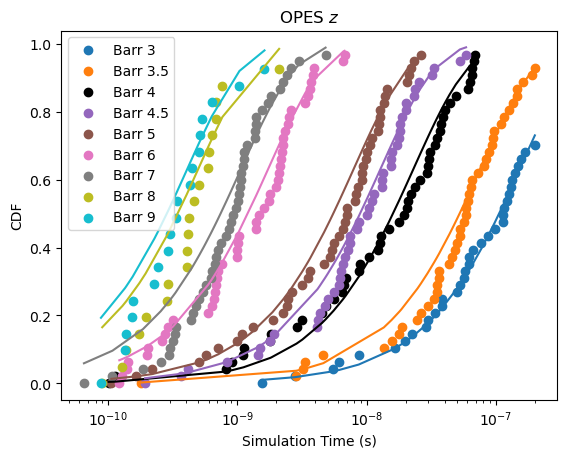

In [4]:
plt.xscale('log')

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_z[barr]),color=colors[i])
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])

plt.title(r'OPES $z$')
plt.xlabel('Simulation Time (s)')
plt.ylabel('CDF')
plt.legend()

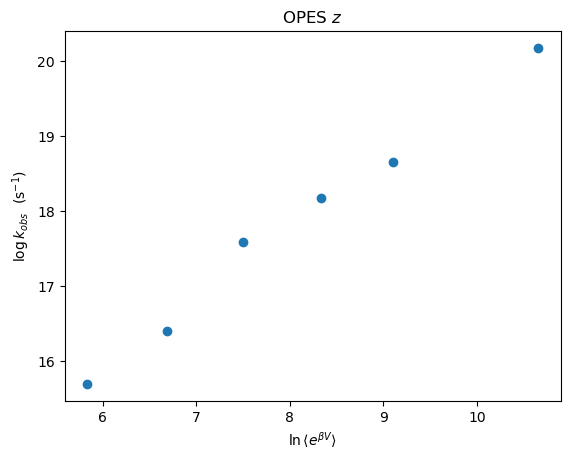

In [5]:
plt.title(r'OPES $z$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{s}^{-1})$')
plt.scatter(avg_ebv_z[:6],[k0s_z[barr][0] for barr in barrs[:6]])

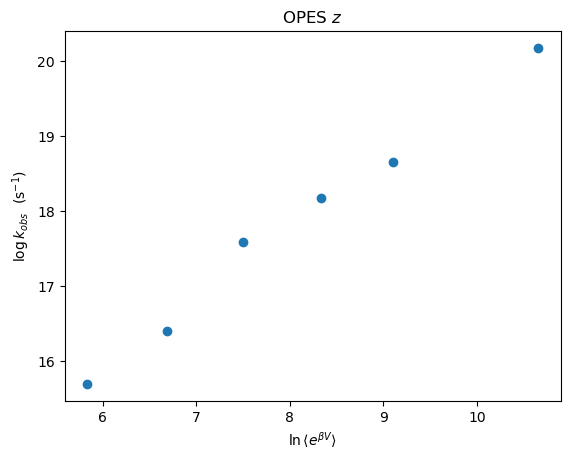

In [6]:
plt.title(r'OPES $z$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{s}^{-1})$')
plt.scatter(avg_ebv_z[:6],[k0s_z[barr][0] for barr in barrs[:6]])

Text(0, 0.5, '$\\ln k_0~~(\\mathrm{s}^{-1})$')

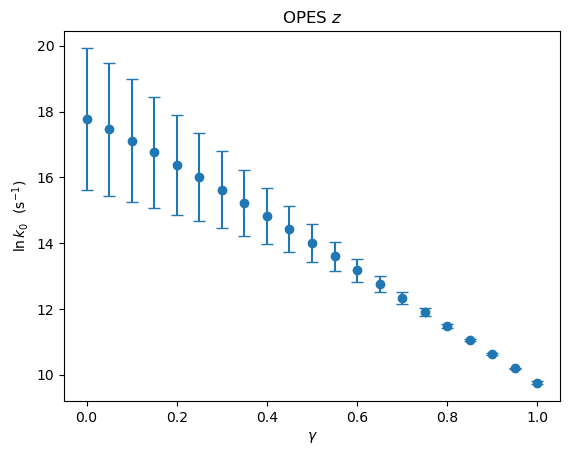

In [7]:
avgs_z = [np.mean([k0s_z[barr][i] for barr in barrs[:6]]) for i in range(len(gammas))]
vars_z = [np.var([k0s_z[barr][i] for barr in barrs[:6]]) for i in range(len(gammas))]

plt.title(r'OPES $z$')
plt.errorbar(gammas,avgs_z,yerr=vars_z,linestyle='',marker='o',capsize=4)
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln k_0~~(\mathrm{s}^{-1})$')

Text(0, 0.5, 'Variance')

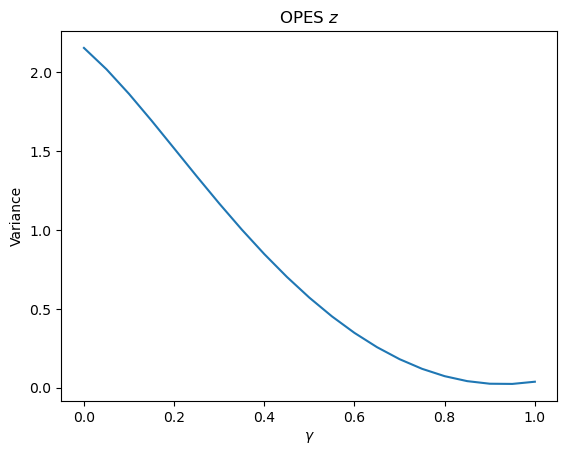

In [8]:
plt.title(r'OPES $z$')
plt.plot(gammas,vars_z)
plt.xlabel(r'$\gamma$')
plt.ylabel('Variance')

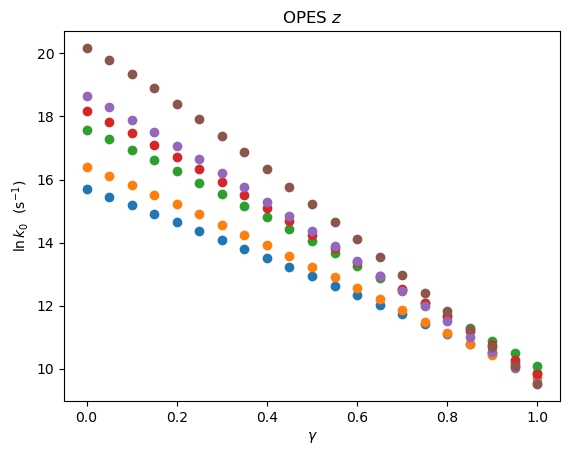

In [9]:
plt.title(r'OPES $z$')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln k_0~~(\mathrm{s}^{-1})$')

for barr in barrs[:6]:
    plt.scatter(gammas,k0s_z[barr])

In [10]:
def variance(gamma):
    k0s = []
    for barr in barrs[:6]:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_z[barr]),axis=0))
        k0s.append(np.log(emp_rates_z[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_z = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs[:6]:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_z*v_datas_z[barr]),axis=0))
    k0s.append(np.log(emp_rates_z[barr])-np.log(avg))
k0_best_z = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_z}, lnk0: {k0_best_z-np.log(1e3)} (ms^-1), k0: {np.exp(k0_best_z)/1e3} ms^-1, τ0: {np.exp(-k0_best_z)*1e3} ms')

LEAST VAR:  gamma: 0.9291514036337009, lnk0: 3.465890063346901 (ms^-1), k0: 32.0049335177767 ms^-1, τ0: 0.03124518285421726 ms


In [11]:
k0s_r = {}
v_datas_r = {}
avg_ebv_r = []
avg_ebv_t_r = {}

gammas = np.linspace(0,1,21)
barrs = ['3','3.5','4','4.5','5','6','7','8','9']

ts_barrs = []
ix_col_barrs_r = []
ys_barrs = []
emp_rates_r = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}


def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_r[barr] = []
    
    colvars = glob(f"../../Data/cavity/P_rho_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity/P_rho_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # colvar_row_counts[int(np.floor(0.8*np.sum(transitioned)))] # -1
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_r[barr] = v_data
    
    emp_rate = transitioned.sum() / final_times.sum()
    emp_rates_r[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')

    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_r[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_r.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        #avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=1))
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_r[barr].append(np.log(emp_rate)-np.log(avg))

22 out of 48 simulations transitioned.
avg. max. bias: 4.017415395833333
tau_obs: 3.399478792122219e-07, k_obs: 2941627.4115824746, log k_obs: 14.894473527521946
Modified KS stat: 0.37106410505837184; p = 0.9700483597985
ln<e^βV>: 5.598163809883635

43 out of 48 simulations transitioned.
avg. max. bias: 4.551632729166667
tau_obs: 8.367670096723462e-08, k_obs: 11950757.958198795, log k_obs: 16.296305261794693
Modified KS stat: 0.5872878730339225; p = 0.8778443369340392
ln<e^βV>: 6.430831859476483

46 out of 48 simulations transitioned.
avg. max. bias: 5.0795171041666665
tau_obs: 3.9485544964696717e-08, k_obs: 25325723.65137878, log k_obs: 17.047331182276313
Modified KS stat: 0.7128028056589887; p = 0.6898302388124118
ln<e^βV>: 7.300870024948724

48 out of 48 simulations transitioned.
avg. max. bias: 5.5944831875
tau_obs: 2.675268854676959e-08, k_obs: 37379420.69828907, log k_obs: 17.436630862233535
Modified KS stat: 1.1471385421688292; p = 0.14383636914951992
ln<e^βV>: 8.088419884350273

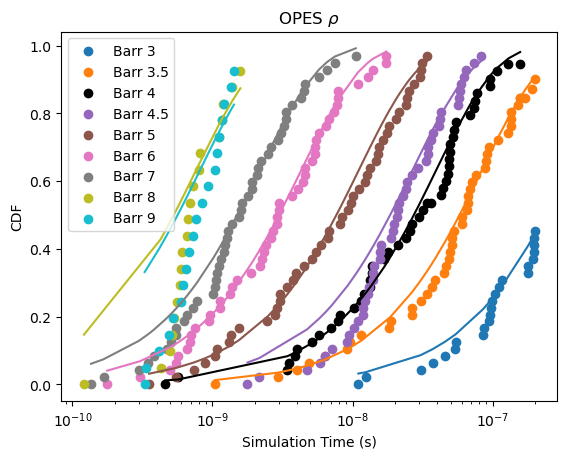

In [12]:
plt.xscale('log')

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_r[barr]),color=colors[i])
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])

plt.title(r'OPES $\rho$')
plt.xlabel('Simulation Time (s)')
plt.ylabel('CDF')
plt.legend()

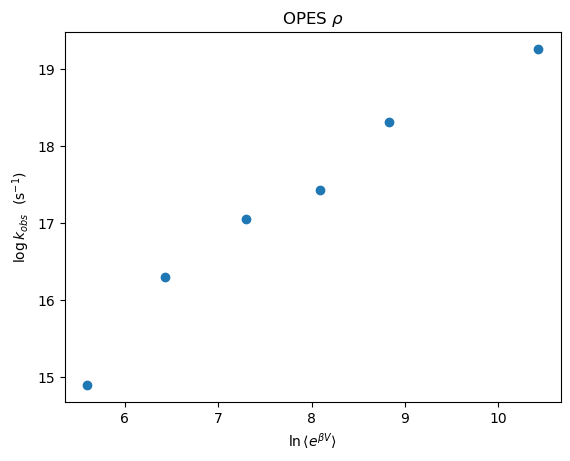

In [13]:
plt.title(r'OPES $\rho$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{s}^{-1})$')
plt.scatter(avg_ebv_r[:6],[k0s_r[barr][0] for barr in barrs[:6]])

Text(0, 0.5, '$\\ln k_0~~(\\mathrm{s}^{-1})$')

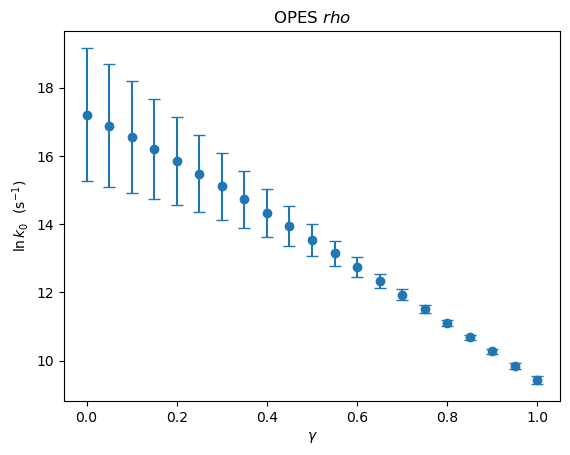

In [14]:
avgs_r = [np.mean([k0s_r[barr][i] for barr in barrs[:6]]) for i in range(len(gammas))]
vars_r = [np.var([k0s_r[barr][i] for barr in barrs[:6]]) for i in range(len(gammas))]

plt.title(r'OPES $rho$')
plt.errorbar(gammas,avgs_r,yerr=vars_r,linestyle='',marker='o',capsize=4)
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln k_0~~(\mathrm{s}^{-1})$')

Text(0, 0.5, 'Variance')

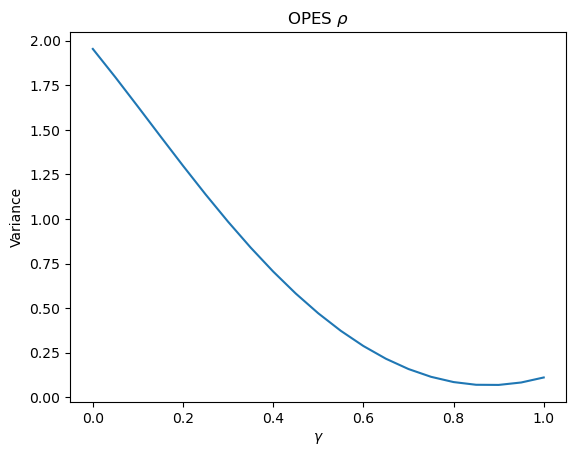

In [15]:
plt.title(r'OPES $\rho$')
plt.plot(gammas,vars_r)
plt.xlabel(r'$\gamma$')
plt.ylabel('Variance')

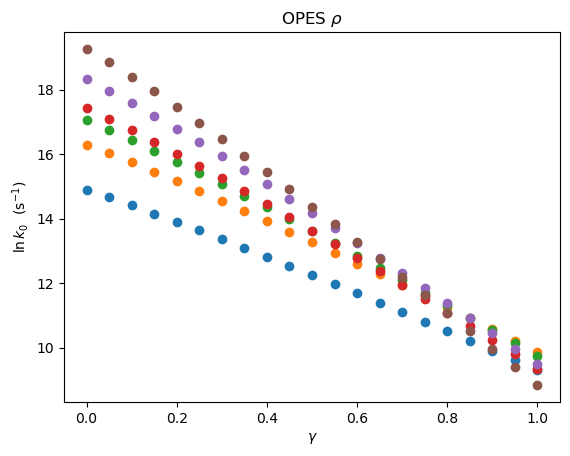

In [16]:
plt.title(r'OPES $\rho$')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln k_0~~(\mathrm{s}^{-1})$')

for barr in barrs[:6]:
    plt.scatter(gammas,k0s_r[barr])

In [17]:
def variance(gamma):
    k0s = []
    for barr in barrs[:6]:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_r[barr]),axis=0))
        k0s.append(np.log(emp_rates_r[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_r = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs[:6]:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_r*v_datas_r[barr]),axis=0))
    k0s.append(np.log(emp_rates_r[barr])-np.log(avg))
k0_best_r = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_r}, lnk0: {k0_best_r-np.log(1e3)} (ms^-1), k0: {np.exp(k0_best_r)/1e3} ms^-1, τ0: {np.exp(-k0_best_r)*1e3} ms')

LEAST VAR:  gamma: 0.8778629751451908, lnk0: 3.5470179557924126 (ms^-1), k0: 34.709657272330745 ms^-1, τ0: 0.028810425644771865 ms


γ Z: 0.9291514036337009
γ P: 0.8778629751451908


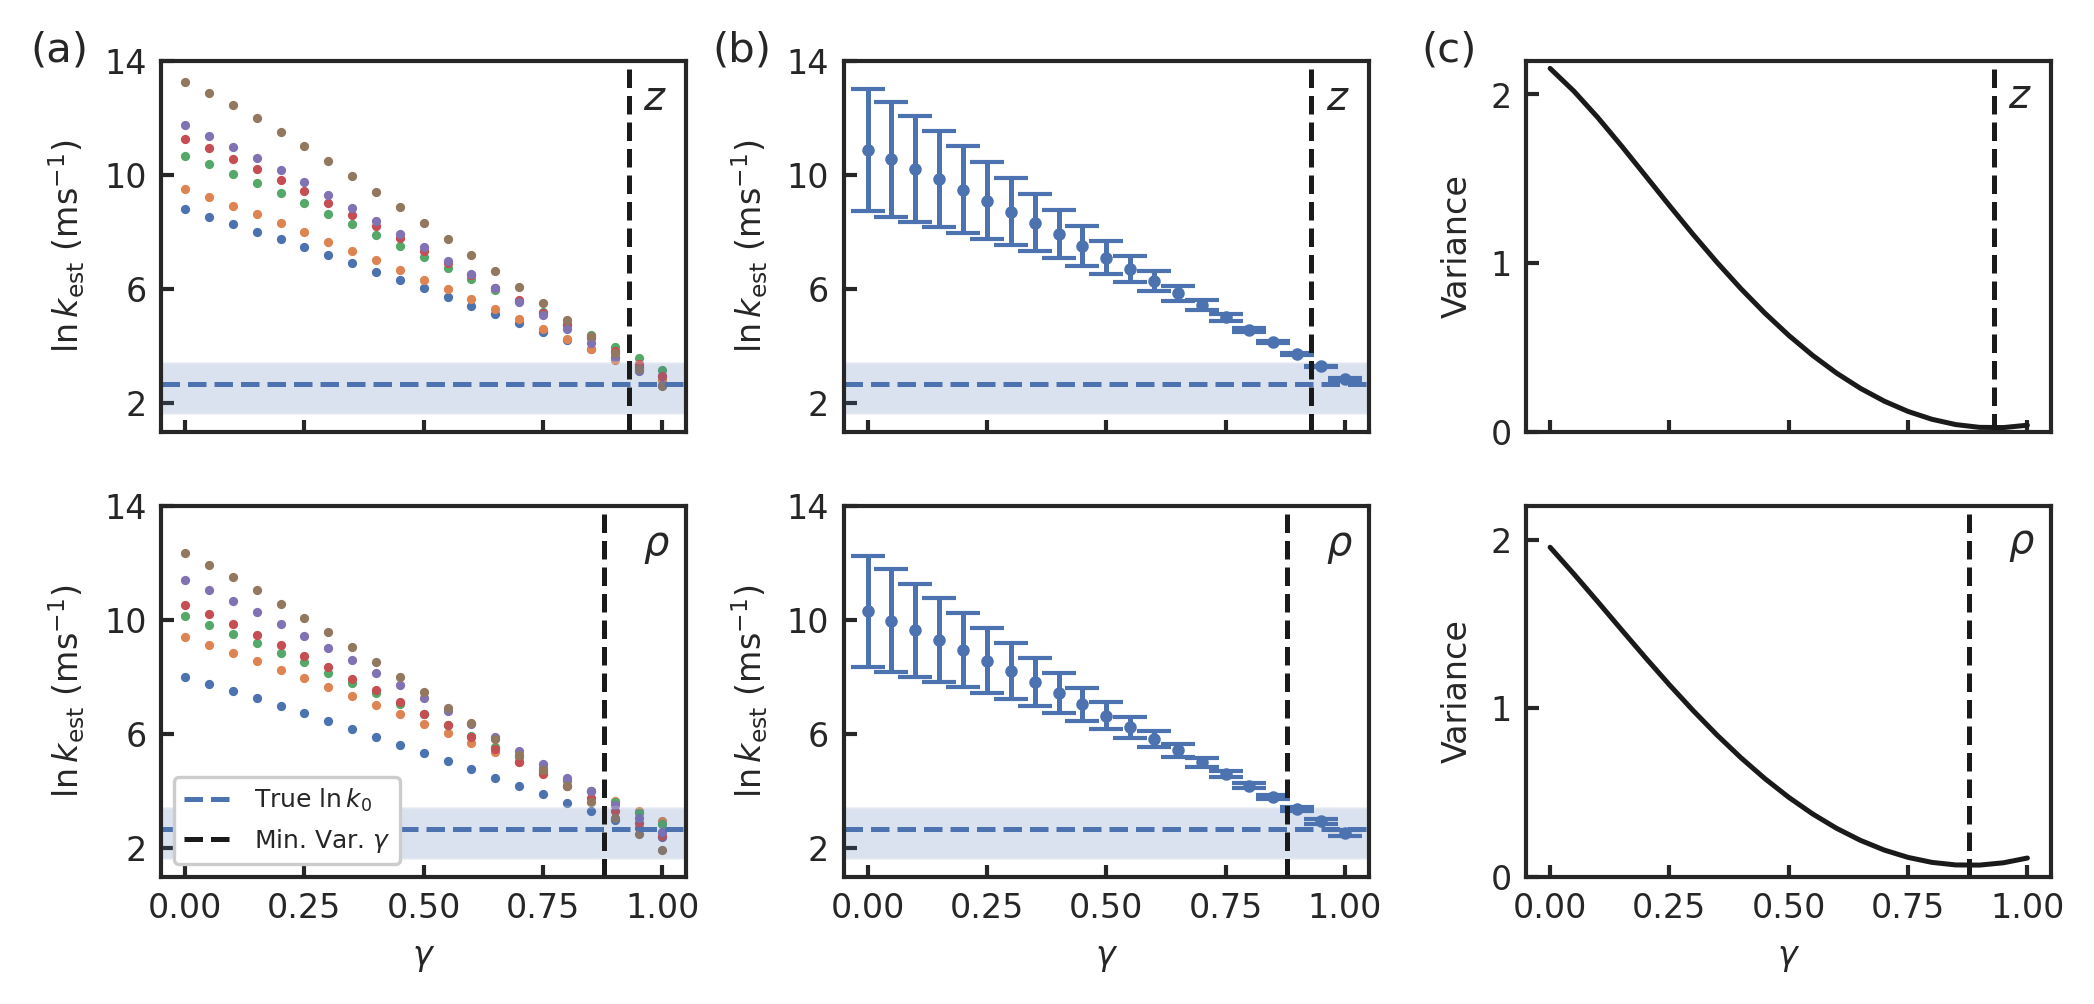

In [18]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

barrs_z = ['3','3.5','4','4.5','5','6']
barrs_r = ['3','3.5','4','4.5','5','6']

fig, axs = plt.subplots(2,3,figsize=(7,3.4),dpi=300,sharey='col',sharex=True)
fig.subplots_adjust(wspace=0.3,bottom=0.12,left=0.07,right=0.97,top=0.92)

for i, barr in enumerate(barrs_z):
    axs[0,0].scatter(gammas,k0s_z[barr]-np.log(1e3),color=f'C{i}',s=2)

for i, barr in enumerate(barrs_r):
    axs[1,0].scatter(gammas,k0s_r[barr]-np.log(1e3),color=f'C{i}',s=2)

axs[0,1].errorbar(gammas,avgs_z-np.log(1e3),yerr=vars_z,linestyle='',marker='o',capsize=4,markersize=2)
axs[1,1].errorbar(gammas,avgs_r-np.log(1e3),yerr=vars_r,linestyle='',marker='o',capsize=4,markersize=2)
axs[0,2].plot(gammas,vars_z,color='k')
axs[1,2].plot(gammas,vars_r,color='k')

axs[0,0].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{ms}^{-1})$')
axs[1,0].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{ms}^{-1})$')
axs[0,1].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{ms}^{-1})$')
axs[1,1].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{ms}^{-1})$')
axs[0,2].set_ylabel('Variance')
axs[1,2].set_ylabel('Variance')
axs[1,0].set_xlabel(r'$\gamma$')
axs[1,1].set_xlabel(r'$\gamma$')
axs[1,2].set_xlabel(r'$\gamma$')
axs[0,2].set_xlim((-0.05,1.05))
axs[1,2].set_xlim((-0.05,1.05))

axs[0,0].set_ylim((1,14))
axs[0,0].set_yticks([2,6,10,14])
axs[0,1].set_ylim((1,14))
axs[0,1].set_yticks([2,6,10,14])
axs[0,2].set_ylim((0,2.2))
axs[0,2].set_yticks([0,1,2])

#axs[0,0].set_title(r'$z$')
#axs[1,0].set_title(r'$\rho$')

right_shift = 0.1
axs[0,0].text(-0.25,1.0,"(a)",fontsize=10,transform=axs[0,0].transAxes)
axs[0,1].text(-0.25,1.0,"(b)",fontsize=10,transform=axs[0,1].transAxes)
axs[0,2].text(-0.2,1.0,"(c)",fontsize=10,transform=axs[0,2].transAxes)
axs[0,0].text(0.96,12.3,r'$z$')
axs[0,1].text(0.96,12.3,r'$z$')
axs[0,2].text(0.96,1.92,r'$z$')
axs[1,0].text(0.96,12.3,r'$\rho$')
axs[1,1].text(0.96,12.3,r'$\rho$')
axs[1,2].text(0.96,1.92,r'$\rho$')

logk0_exp = 2.67
logk0_lowci = 1.62
logk0_highci = 3.44

for i in range(2):
    for j in range(2):
        axs[j,i].axhline(logk0_exp,linestyle='--',color='C0',label=r'True $\ln k_0$')
        axs[j,i].fill_between([-0.05,1.05],logk0_lowci,logk0_highci,alpha=0.2)

axs[0,0].axvline(gamma_best_z,linestyle='--',color='k')
axs[0,1].axvline(gamma_best_z,linestyle='--',color='k')
axs[0,2].axvline(gamma_best_z,linestyle='--',color='k')
print(f'γ Z: {gamma_best_z}')
axs[1,0].axvline(gamma_best_r,linestyle='--',color='k',label=r'Min. Var. $\gamma$')
axs[1,1].axvline(gamma_best_r,linestyle='--',color='k')
axs[1,2].axvline(gamma_best_r,linestyle='--',color='k')
print(f'γ P: {gamma_best_r}')

for ax in axs.flatten():
    ax.tick_params(axis='both', direction='in', which='both', length=3)

axs[1,0].legend(framealpha=1,loc='lower left')
plt.savefig("EATRf_Fig6.pdf",format='pdf')

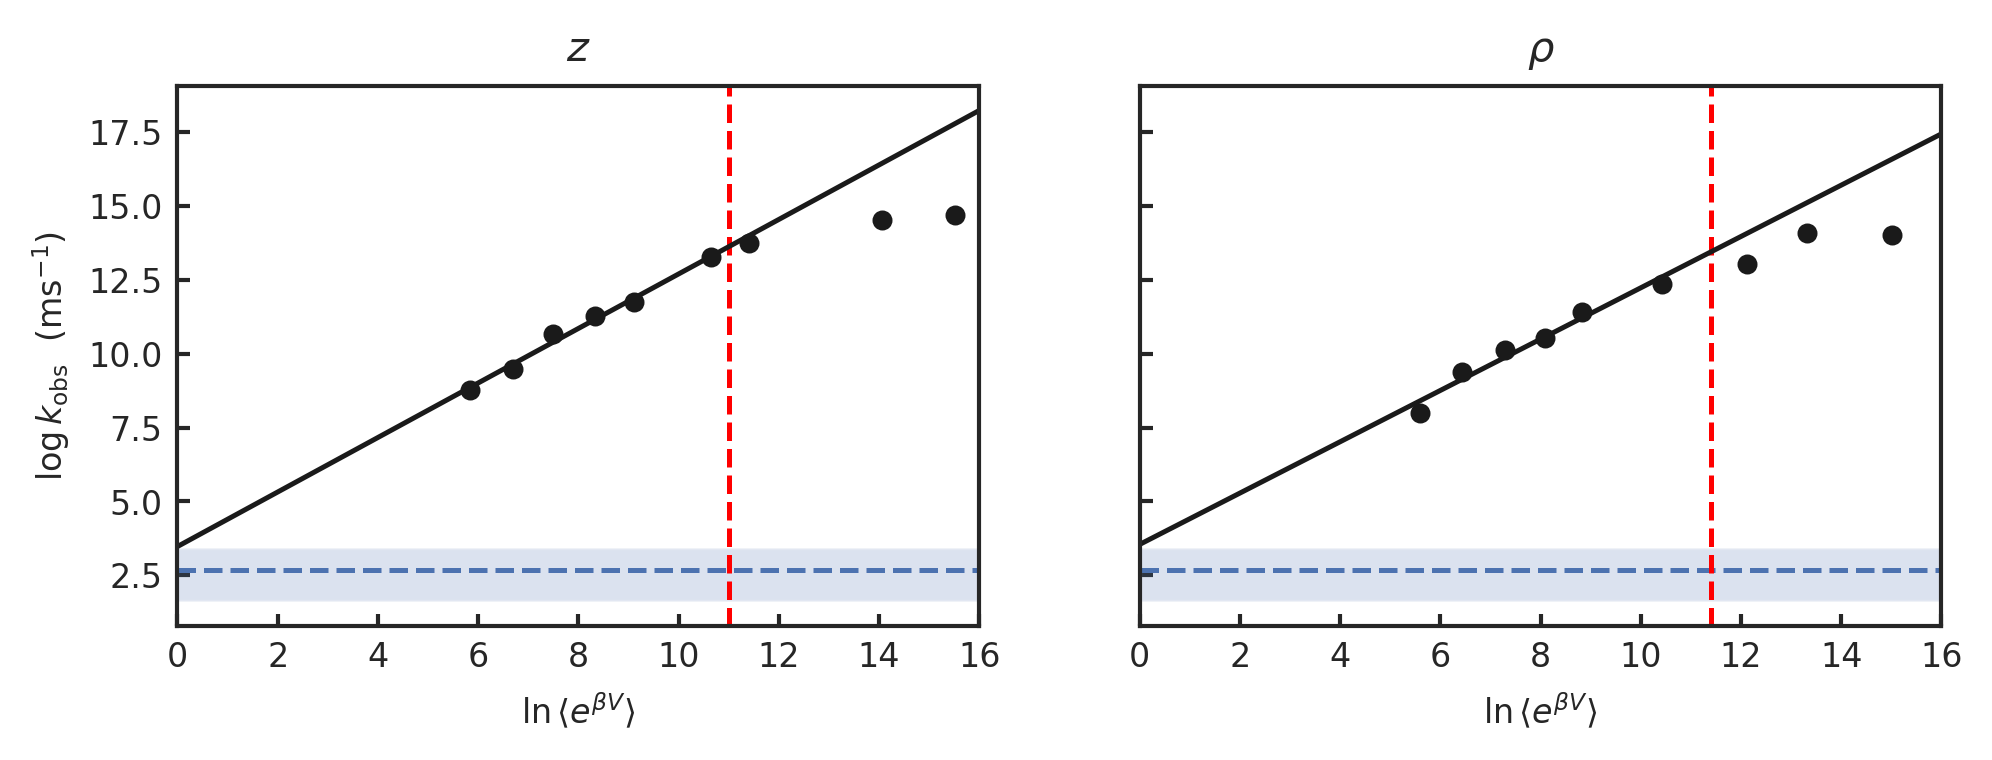

In [19]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

barrs_z = ['3','3.5','4','4.5','5','6','7','8','9']
barrs_r = ['3','3.5','4','4.5','5','6','7','8','9']

fig, axs = plt.subplots(1,2,figsize=(7,3),dpi=300,sharey=True,sharex=True)
fig.subplots_adjust(wspace=0.2,bottom=0.25,left=0.13,right=0.97,top=0.85)

#axs[0,0].set_ylim((-18,-8))
#axs[0].set_yticks([15,18,21])
#axs[1,0].set_ylim((-18,-8))
#axs[1,0].set_yticks([-9,-12,-15,-18])

axs[0].scatter(avg_ebv_z,[k0s_z[barr][0]-np.log(1e3) for barr in barrs_z],color='k')
axs[1].scatter(avg_ebv_r,[k0s_r[barr][0]-np.log(1e3) for barr in barrs_r],color='k')

logk0_exp = 2.67
logk0_lowci = 1.62
logk0_highci = 3.44

axs[0].axhline(logk0_exp,linestyle='--',color='C0',label=r'True $\ln k_0$')
axs[0].fill_between([0,16],logk0_lowci,logk0_highci,alpha=0.2)
axs[1].axhline(logk0_exp,linestyle='--',color='C0',label=r'True $\ln k_0$')
axs[1].fill_between([0,16],logk0_lowci,logk0_highci,alpha=0.2)

axs[0].set_xlim((0,16))
axs[0].axvline(11,color='#FF0000',linestyle='--')
axs[1].axvline(11.4,color='#FF0000',linestyle='--')

line_x = [0,16]
line_func = lambda m,b,x: m*x+b
inter,slope = optimize.curve_fit(line_func,avg_ebv_z[:6],[k0s_z[barr][0]-np.log(1e3) for barr in barrs_z[:6]])[0]
axs[0].plot(line_x,line_func(slope,inter,np.array(line_x)),linestyle='-',color='k')
inter,slope = optimize.curve_fit(line_func,avg_ebv_r[:6],[k0s_r[barr][0]-np.log(1e3) for barr in barrs_r[:6]])[0]
axs[1].plot(line_x,line_func(slope,inter,np.array(line_x)),linestyle='-',color='k')

axs[0].set_ylabel(r'$\log k_\mathrm{obs}~~(\mathrm{ms}^{-1})$')
axs[0].set_xlabel(r'$\ln \langle e^{\beta V} \rangle$')
axs[1].set_xlabel(r'$\ln \langle e^{\beta V} \rangle$')

axs[0].set_title(r'$z$')
axs[1].set_title(r'$\rho$')

for ax in axs.flatten():
    ax.tick_params(axis='both', direction='in', which='both', length=3)

#axs[0,1].legend(framealpha=1)
plt.savefig("EATRf_FigS6.pdf",format='pdf')

In [20]:
k0s_095zt = {}
v_datas_095zt = {}
avg_ebv_095zt = []
avg_ebv_t_095zt = {}

gammas = np.linspace(0,1,21)
barrs = ['3.5','4','4.5','5','5.5','6']

ts_barrs = []
ix_col_barrs_095zt = []
ys_barrs = []
emp_rates_095zt = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}


def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_095zt[barr] = []
    
    colvars = glob(f"../../Data/cavity/Z_95_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity/Z_95_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # colvar_row_counts[int(np.floor(0.8*np.sum(transitioned)))] # -1
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    
    emp_rate = transitioned.sum() / final_times.sum()
    emp_rates_095zt[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')

    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_095zt[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_095zt.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        #avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=1))
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_095zt[barr].append(np.log(emp_rate)-np.log(avg))

36 out of 48 simulations transitioned.
avg. max. bias: 4.327236416666666
tau_obs: 1.1276631091166767e-07, k_obs: 8867896.73188229, log k_obs: 15.997948204621474
Modified KS stat: 0.49225093992912367; p = 0.9602138932619729
ln<e^βV>: 6.551068851088087

41 out of 48 simulations transitioned.
avg. max. bias: 4.8736336875
tau_obs: 5.1786880508525124e-08, k_obs: 19309909.96523493, log k_obs: 16.776128991795947
Modified KS stat: 0.45930393406244385; p = 0.9841028554346886
ln<e^βV>: 7.4195055959323115

44 out of 48 simulations transitioned.
avg. max. bias: 5.43233875
tau_obs: 2.7509524033904975e-08, k_obs: 36351046.95986447, log k_obs: 17.408733563726123
Modified KS stat: 0.8333407189510987; p = 0.4909336960019708
ln<e^βV>: 8.2347485651707

47 out of 48 simulations transitioned.
avg. max. bias: 5.963274041666668
tau_obs: 1.522178795703862e-08, k_obs: 65695304.83687995, log k_obs: 18.00053801723117
Modified KS stat: 1.0323678618392211; p = 0.2369060638472572
ln<e^βV>: 9.057441815019587

47 out

In [21]:
k0s_09zt = {}
v_datas_09zt = {}
avg_ebv_09zt = []
avg_ebv_t_09zt = {}

gammas = np.linspace(0,1,21)
barrs = ['3.5','4','4.5','5','5.5','6']

ts_barrs = []
ix_col_barrs_09zt = []
ys_barrs = []
emp_rates_09zt = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}


def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_09zt[barr] = []
    
    colvars = glob(f"../../Data/cavity/Z_90_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity/Z_90_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # colvar_row_counts[int(np.floor(0.8*np.sum(transitioned)))] # -1
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    
    emp_rate = transitioned.sum() / final_times.sum()
    emp_rates_09zt[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')

    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_09zt[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_09zt.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        #avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=1))
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_09zt[barr].append(np.log(emp_rate)-np.log(avg))

22 out of 48 simulations transitioned.
avg. max. bias: 4.221603166666667
tau_obs: 3.0943119651537416e-07, k_obs: 3231736.2026240127, log k_obs: 14.988530074816747
Modified KS stat: 0.42405519548981535; p = 0.9370393986997663
ln<e^βV>: 6.414164392492203

33 out of 48 simulations transitioned.
avg. max. bias: 4.750486541666667
tau_obs: 1.2317946039616458e-07, k_obs: 8118236.569504706, log k_obs: 15.909623517309509
Modified KS stat: 0.728220412073149; p = 0.6297911518914836
ln<e^βV>: 7.267219954265916

36 out of 48 simulations transitioned.
avg. max. bias: 5.2974396875
tau_obs: 8.561128184409522e-08, k_obs: 11680703.506122913, log k_obs: 16.273448765239106
Modified KS stat: 0.6259413396766267; p = 0.8223179658134945
ln<e^βV>: 8.152035326379282

41 out of 48 simulations transitioned.
avg. max. bias: 5.857112958333334
tau_obs: 3.939253845641093e-08, k_obs: 25385518.151020683, log k_obs: 17.049689417855955
Modified KS stat: 0.4528660620442824; p = 0.985216388044272
ln<e^βV>: 8.96503018799127

In [22]:
k0s_087zt = {}
v_datas_087zt = {}
avg_ebv_087zt = []
avg_ebv_t_087zt = {}

gammas = np.linspace(0,1,21)
barrs = ['3.5','4','4.5','5','5.5','6']#,'7','8','9']

ts_barrs = []
ix_col_barrs_087zt = []
ys_barrs = []
emp_rates_087zt = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}


def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_087zt[barr] = []
    
    colvars = glob(f"../../Data/cavity/Z_87_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity/Z_87_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # colvar_row_counts[int(np.floor(0.8*np.sum(transitioned)))] # -1
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    
    emp_rate = transitioned.sum() / final_times.sum()
    emp_rates_087zt[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')

    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_087zt[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_087zt.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        #avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=1))
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_087zt[barr].append(np.log(emp_rate)-np.log(avg))

29 out of 48 simulations transitioned.
avg. max. bias: 4.180370145833333
tau_obs: 3.054047731266372e-07, k_obs: 3274343.0620363825, log k_obs: 15.001627815185659
Modified KS stat: 0.32036046554178765; p = 0.9988886655652469
ln<e^βV>: 6.363332773208927

27 out of 48 simulations transitioned.
avg. max. bias: 4.7172039791666664
tau_obs: 3.245346450441971e-07, k_obs: 3081335.12175199, log k_obs: 14.94087354211228
Modified KS stat: 0.4983692576164729; p = 0.9080409474541953
ln<e^βV>: 7.2381604066703655

37 out of 48 simulations transitioned.
avg. max. bias: 5.251524479166666
tau_obs: 1.3611070916761419e-07, k_obs: 7346960.471483146, log k_obs: 15.809797244362427
Modified KS stat: 0.4497677261511681; p = 0.9844814128235423
ln<e^βV>: 8.097903935866253

34 out of 48 simulations transitioned.
avg. max. bias: 5.801809479166667
tau_obs: 8.718735708235357e-08, k_obs: 11469552.85105662, log k_obs: 16.255206504130882
Modified KS stat: 0.7135206083278324; p = 0.6875622889279344
ln<e^βV>: 8.9617076365

0.9223546776736734
0.8565552369685386
0.6848387475719477
0.5720128729413037


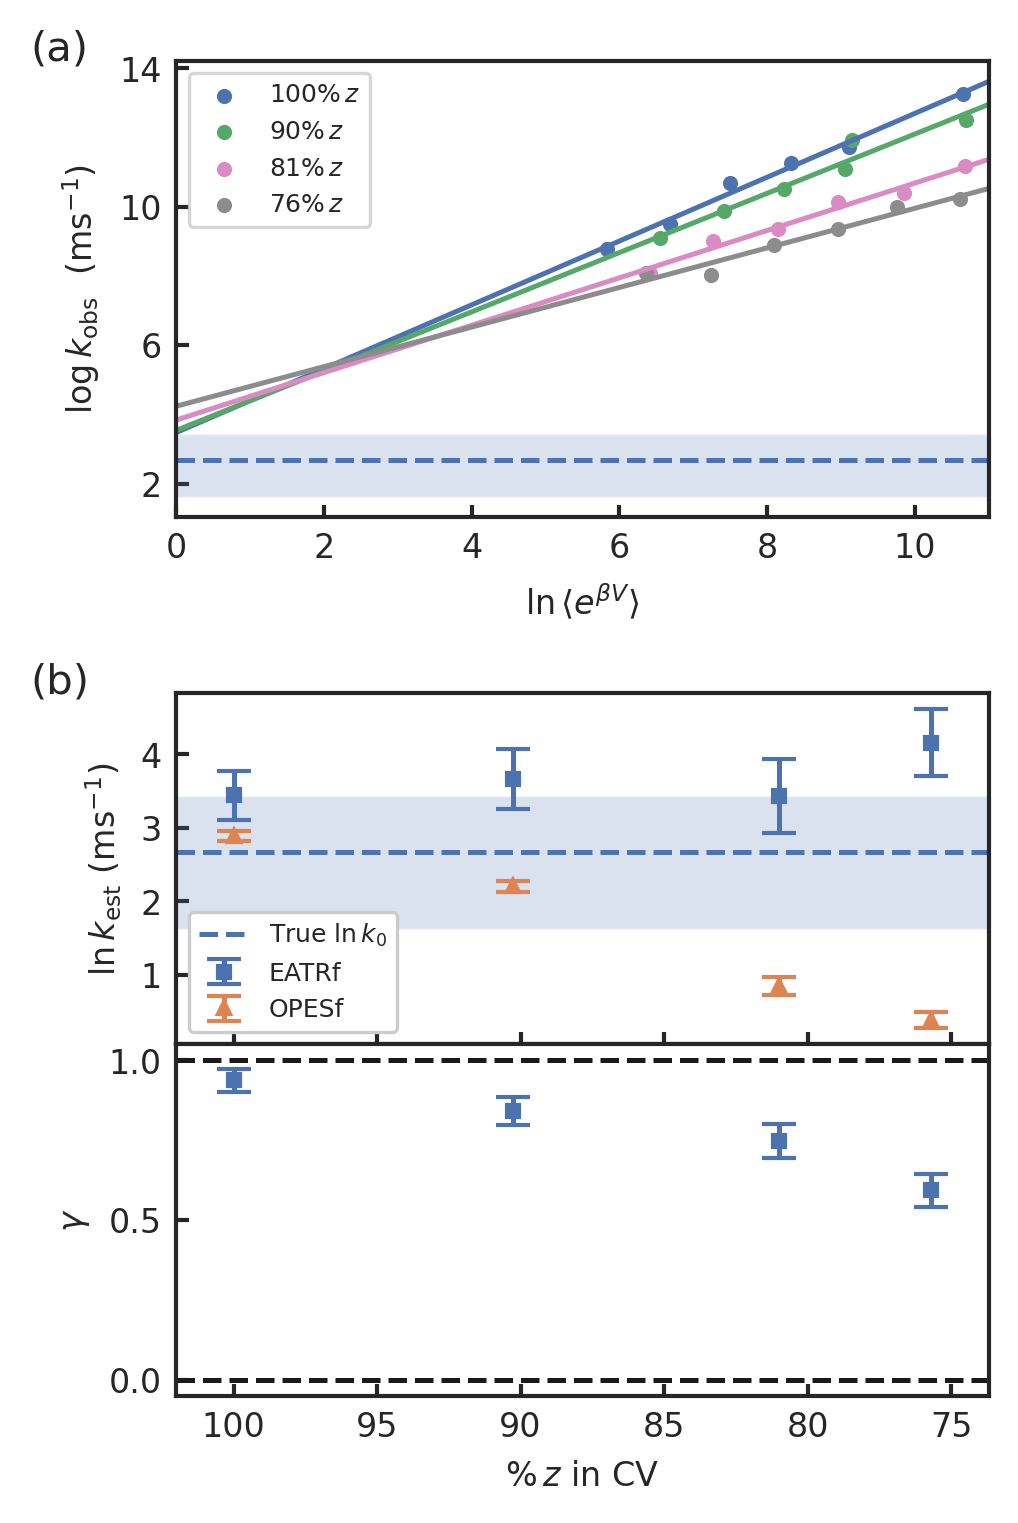

In [24]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

gs = dict(hspace=0.0, height_ratios=[1.3, 0.5, 1, 1])

fig, axs = plt.subplots(4,1,figsize=(3.3432,5),dpi=300,sharey='row',sharex=False,gridspec_kw=gs)
fig.subplots_adjust(wspace=0.25,hspace=0,bottom=0.08,left=0.15,right=0.96,top=0.97)

axs[1].set_visible(False)

for ax in axs.flatten():
    ax.tick_params(axis='both', direction='in', which='both', length=3)

logk0_exp = 2.67
logk0_lowci = 1.62
logk0_highci = 3.44
barrs_zr = ['3','3.5','4','4.5','5','6']
barrs_zt = ['3.5','4','4.5','5','5.5','6']

def add_trendline(xdata,ydata,color='C0',linestyle='-',add_zero=False):
    line_x = [5.5,11]
    if add_zero:
        line_x[0] = 0
    line_func = lambda m,b,x: m*x+b
    inter,slope = optimize.curve_fit(line_func,xdata,ydata)[0]
    print(slope)
    axs[0].plot(line_x,line_func(slope,inter,np.array(line_x)),linestyle=linestyle,color=color)

axs[0].scatter(avg_ebv_z[:6],[k0s_z[barr][0]-np.log(1e3) for barr in barrs_zr],color='C0',s=8,label=r'$100\%\,z$')
add_trendline(avg_ebv_z[:6],[k0s_z[barr][0]-np.log(1e3) for barr in barrs_zr],color='C0',add_zero=True)
axs[0].scatter(avg_ebv_095zt,[k0s_095zt[barr][0]-np.log(1e3) for barr in barrs_zt],color='C2',s=8,label=r'$90\%\,z$')
add_trendline(avg_ebv_095zt,[k0s_095zt[barr][0]-np.log(1e3) for barr in barrs_zt],color='C2',add_zero=True)
axs[0].scatter(avg_ebv_09zt,[k0s_09zt[barr][0]-np.log(1e3) for barr in barrs_zt],color='C6',s=8,label=r'$81\%\,z$')
add_trendline(avg_ebv_09zt,[k0s_09zt[barr][0]-np.log(1e3) for barr in barrs_zt],color='C6',add_zero=True)
axs[0].scatter(avg_ebv_087zt,[k0s_087zt[barr][0]-np.log(1e3) for barr in barrs_zt],color='C7',s=8,label=r'$76\%\,z$')
add_trendline(avg_ebv_087zt,[k0s_087zt[barr][0]-np.log(1e3) for barr in barrs_zt],color='C7',add_zero=True)

axs[0].set_ylabel(r'$\log k_\mathrm{obs}~~(\mathrm{ms}^{-1})$')
axs[0].set_xlabel(r'$\ln \langle e^{\beta V} \rangle$')
axs[0].set_yticks([2,6,10,14])
axs[0].legend()

axs[0].tick_params(axis='both', direction='in', which='both', length=3)
axs[0].axhline(logk0_exp,linestyle='--',color='C0',label=r'True $\ln k_0$')
axs[0].fill_between([0,12],logk0_lowci,logk0_highci,alpha=0.2)
axs[0].set_xlim((0,11))
axs[0].text(-0.18,1.0,"(a)",fontsize=10,transform=axs[0].transAxes)

alphas = np.array([0.87,0.9,0.95,1.0])
gammas = np.array([0.5935069087279032,0.7476985141039822,0.841826923403474,0.9373380176072776])
gammas_errors = np.array([0.051828764347021314,0.05425265700272211,0.04388072863864018,0.037171351845583574])
logk0s = np.array([11.066907860293181,10.338441387592976,10.572874585666039,10.349933956353071])
logk0s_errors = np.array([0.4557486326903295,0.5066296041887342,0.40191613759077377,0.3330355233449323])
opesfs = np.array([7.293243369203607,7.760169984526217,9.113769335418137,9.798173871340452])
opesfs_errors = np.array([0.11243456647339793,0.12040203009242033,0.07599565347038195,0.07387543537529165])

axs[2].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{ms}^{-1})$')
axs[2].set_xlim((87*0.87-2,102))
axs[2].axhline(logk0_exp,linestyle='--',color='C0',label=r'True $\ln k_0$')
axs[2].errorbar(100*alphas*alphas,logk0s-np.log(1e3),yerr=logk0s_errors,linestyle='',marker='s',capsize=4,markersize=3,label='EATRf')
axs[2].errorbar(100*alphas*alphas,opesfs-np.log(1e3),yerr=opesfs_errors,linestyle='',marker='^',capsize=4,markersize=3,label='OPESf')
axs[2].fill_between([70,105],logk0_lowci,logk0_highci,alpha=0.2)
axs[2].legend(framealpha=1)
axs[2].invert_xaxis()

axs[3].set_ylabel(r'$\gamma$')
axs[3].set_xlabel(r'$\%\,z$ in CV')
axs[3].set_xlim((87*0.87-2,102))
axs[3].set_xticks([75,80,85,90,95,100])
axs[3].set_ylim((-0.05,1.05))
axs[3].set_yticks([0,0.5,1])
axs[3].axhline(0,linestyle='--',color='k')
axs[3].axhline(1,linestyle='--',color='k')
axs[3].errorbar(100*alphas*alphas,gammas,yerr=gammas_errors,linestyle='',marker='s',capsize=4,markersize=3)
axs[3].invert_xaxis()


axs[2].text(-0.18,1.0,"(b)",fontsize=10,transform=axs[2].transAxes)

plt.savefig("EATRf_Fig7.pdf",format='pdf')